In [16]:
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
from matplotlib import pyplot as plt
from src.data_format import format_output
from src.data import DATA_OUT_PROC, DATA_FIGURE, DATA_IN_JSONS, DATA_LABELLED
from src.accuracy import *
from src.utils import *
from src.impact_def import IMPACT_SUBTYPES_MERGED
from src.utils import MODEL_NAMES_MAP, normalize_flags, get_flag_cols


## Coverage with accuracy

In [17]:
# load data extracted for a specific model


keys = ["meta-llama_llama-4-scout-17b-16e-instruct", "llama-3.1-8b-instant", "llama-3.3-70b-versatile"]
key = keys[0]
res_savename_ext = "post_processed_0-39_labelled_reports_meta-llama_llama-4-scout-17b-16e-instruct_v070726_v080726_geo"
#"post_processed_labelled_reports_1quali_chunksize1000_Noneit_meta-llama_llama-4-scout-17b-16e-instruct_v300626_v300626_geo"
# "post_processed_0-39_labelled_reports_meta-llama_llama-4-scout-17b-16e-instruct_v070726_v080726_geo"


# load data (labelled)
res_savename_lab = "post_processed_labelled_reports_all_v09072026_v090726_geo"  # merged_subtypes_

split_lowest = False
suffix = "_geo_split_lowest" if split_lowest else "_geo"
suffix2 = suffix + "_v271025"
suffix3 = suffix + "_v171025"
# load geocoded data
extracted_df = gpd.read_file(DATA_OUT_PROC / (res_savename_ext+".gpkg"))
labelled_df = gpd.read_file(DATA_OUT_PROC / (res_savename_lab+".gpkg"))
# load corresponding matched data
ws_key_qt = "ws_quanti_opt"
ws_key_ql = "ws_quali_opt"
filename_match = f"matched_data_by_labelled_{ws_key_qt}qt-{ws_key_ql}ql-geo-valuepre-loose-nans_{res_savename_ext}"
# f"matched_data_ws2-geo-valuepre-strict-nans_{res_savename_ext}"
matched_df = gpd.read_feather(DATA_OUT_PROC / (filename_match + ".feather"))

DEF_CRS_EPSG = "EPSG:4326"
drop_appeals = []
#drop_appeals = [
#   "MDRCO023",
#   "MDRGW003",
#   "MDRHU005",
#   "MDRPH021",
#   "MDRRS015",
#   "MDRMN017",
#   "MDRGT009",
#   "MDRPG008",
#   "MDREC019",
#   "MDRTN010",
#   "MDRCR012",
#   "MDRGE019",]

keep_appeals = [appeal for appeal in extracted_df["appealCode"].unique() if appeal not in drop_appeals]
for name in ["matched_df", "extracted_df", "labelled_df"]:
    df = locals()[name]
    df = format_output(df)
    if "quanti" not in df.columns:
        df["quanti"] = df["impactValue"].notnull()
        df.loc[df["quanti"],"quanti"] = "quanti"
        df.loc[df["quanti"]==False,"quanti"] = "quali"
    df = df.set_crs(DEF_CRS_EPSG, allow_override=True)
    df = df[df["appealCode"].isin(keep_appeals)]
    locals()[name] = df  # assign back

# compute metrics
matched_df["impactValue_error"] = matched_df["impactValue_error"].replace([np.inf], np.nan)
matched_df["impactValue_sim"] = matched_df.apply(lambda x: 1-max_value_diff(x["impactValue"], x["impactValue_matched"]).clip(0,1), axis=1)

In [18]:
matched_df.appealCode.nunique()

39

In [19]:
labelled_df.impactSubtype.value_counts()

impactSubtype
Affected People                                134
Residential Buildings                          124
Agriculture and Access to Food                  67
Human Deaths                                    49
Water, Sanitation, and Hygiene                  45
Transportation                                  44
Displaced People                                41
Economy and Livelihood                          37
Undefined Infrastructure and Service Access     33
Injured People                                  27
DREF Allocation & Funding requirements          26
Infected and Ill People                         26
Healthcare                                      22
Education                                       18
Human Health and Wellbeing                      14
Assisted People                                 13
Targeted People                                 11
Informal Settlements                            10
Missing People                                   9
Homeless People  

In [20]:
extracted_df.impactSubtype.value_counts()

impactSubtype
Affected People                                151
Residential Buildings                          117
Agriculture and Access to Food                 104
Water, Sanitation, and Hygiene                  71
DREF Allocation & Funding requirements          67
Displaced People                                50
Human Deaths                                    49
Assisted People                                 48
Economy and Livelihood                          48
Targeted People                                 45
Transportation                                  37
Healthcare                                      36
Homeless People                                 29
Human Health and Wellbeing                      28
Infected and Ill People                         26
Injured People                                  25
Education                                       17
Missing People                                   9
Informal Settlements                             7
Undefined Infrast

In [21]:
## add other variables useful for analysis
# report type
file_path = (
    DATA_IN_JSONS
    / "preproc_text_sel_gaps_all_ifrc_reports_info_unnested_with_text_v181125_v050326.csv"
)  #'all_ifrc_reports_info_processed_extended_format_nb_std_units.json' "nathaz_ifrc_reports_info_processed.json"
ifrc_reports_df = pd.read_csv(file_path)

keys = labelled_df[['appealCode', 'reportDate']].drop_duplicates()
labelled_reports_raw = ifrc_reports_df.merge(keys, on=['appealCode', 'reportDate'], how='inner')
labelled_reports_raw["reportSize"] = labelled_reports_raw["nathaz_text"].apply(len)


# add vars to dfs
extracted_df = extracted_df.merge(labelled_reports_raw[["appealCode", "reportDate", "appealType", "reportSize"]], how="left", on=["appealCode", "reportDate"])
labelled_df = labelled_df.merge(labelled_reports_raw[["appealCode", "reportDate", "appealType", "reportSize"]], how="left", on=["appealCode", "reportDate"])
matched_df = matched_df.merge(labelled_reports_raw[["appealCode", "reportDate", "appealType", "reportSize"]], how="left", on=["appealCode", "reportDate"])

In [22]:
from src.labelling_helpers import filter_reports
ifrc_reports_df_filtered = filter_reports(ifrc_reports_df, take_latest=True)

/Users/lseverino/Documents/PhD/Projects/Como/como_project4/src/labelling_helpers.py:76: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: sort_appeal_type(x))
/Users/lseverino/Documents/PhD/Projects/Como/como_project4/src/labelling_helpers.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sort_values(date_field, ascending=False).head(1))


In [23]:
from src.sanity_checks import flag_remove_cat
#remove_cats = [
#    "Unknown",
#    "DREF Allocation & Funding requirements",
#    "Targeted People",
#    "Assisted People",
#    "Other Human Impacts",
#    "Other Infrastructural Impacts",
#    "Other Agricultural Impacts",
#    "Other Service Access Impacts",
#]  # "Human Health and Wellbeing", "Economy and Livelihood"
#extracted_df["flag_remove_cat"] = extracted_df.apply(flag_remove_cat, remove_cats=remove_cats, axis=1)
#labelled_df["flag_remove_cat"] = labelled_df.apply(flag_remove_cat, remove_cats=remove_cats, axis=1)
#matched_df["flag_remove_cat"] = matched_df.apply(flag_remove_cat, remove_cats=remove_cats, axis=1)

In [80]:
# define threshold above which we consider a match

value_error_th = 0.05
sim_th = 0.5
match_cats_quali = ["impactSubtype"]
filter_flags = [
    "flag_remove_cat",
    "flag_percent",
    "flag_value_no_unit",
    "flag_unit_nonstd",
    "flag_response_unit",
    "flag_unknown_subtype",
    "flag_all_hazards_unknown",
    "flag_pop_cntry",
    "flag_remove_unit",
    "flag_remove_hazard",
    "flag_failed_startYear_inference",
    "flag_inconsistent_year",
    "flag_country_location_missing",
]  # ["flag_unit_nonstd"
keep_vars = ["appealType", "reportSize", "reportDate"]

extracted_df[filter_flags] = extracted_df[filter_flags].map(normalize_flags)
labelled_df[filter_flags] = labelled_df[filter_flags].map(normalize_flags)
matched_df[filter_flags] = matched_df[filter_flags].map(normalize_flags)
extracted_df_filter = filter_by_flags(extracted_df, flag_filters=filter_flags)
labelled_df_filter = filter_by_flags(labelled_df, flag_filters=filter_flags)
matched_df_filter1 = filter_by_flags(matched_df, flag_filters=filter_flags)
matched_df_filter2 = filter_matches(matched_df_filter1, value_error_th=value_error_th, sim_th=sim_th, match_cat=match_cats_quali)
missed_df = labelled_df_filter[~labelled_df_filter.index.isin(matched_df_filter2["lab_match_id_sim"])]
# add report size to missed_df

false_positives_df = extracted_df_filter[~extracted_df_filter.index.isin(matched_df_filter2["ext_match_id_sim"])]
coverage_df_match = make_coverage_accuracy_df(extracted_df_filter, labelled_df_filter, matched_df_filter2, group_key=None)
coverage_df_match_appeal = make_coverage_accuracy_df(extracted_df_filter, labelled_df_filter, matched_df_filter2, group_key="appealCode", keep_vars=keep_vars).reset_index(drop=False, names=["appealCode"])
coverage_df_match_subtype = make_coverage_accuracy_df(extracted_df_filter, labelled_df_filter, matched_df_filter2, group_key="impactSubtype", group_keys=IMPACT_SUBTYPES_MERGED).reset_index(drop=False, names=["impactSubtype"])

In [81]:
extracted_df_filter[extracted_df_filter["quanti"] == "quanti"].shape[0], labelled_df_filter[labelled_df_filter["quanti"] == "quanti"].shape[0]

(495, 464)

In [82]:
extracted_df_filter[extracted_df_filter["quanti"] == "quali"].shape[
    0
], labelled_df_filter[labelled_df_filter["quanti"] == "quali"].shape[0]

(243, 227)

In [83]:
extracted_df_filter.impactSubtype.nunique()

20

In [84]:
labelled_df_filter.impactSubtype.nunique()

20

In [85]:
extracted_df_filter.hazards.explode().nunique()

14

In [86]:
labelled_df_filter.hazards.explode().nunique()

13

In [87]:
missed_df.appealCode.value_counts()

appealCode
MDRYE011    22
MDRUG050    16
MDRPK018    16
MDRKE058    14
MDRBJ019    12
MDRRS015    11
MDRSD034    11
MDRCM036     6
MDRSV012     6
MDRPH036     5
MDRNG041     5
MDRRW022     5
MDRLB013     5
MDRS2001     4
MDRDZ011     4
MDRPK026     4
MDRJO003     3
MDRBD022     3
MDRMZ024     3
MDRIQ014     2
MDRUY004     2
MDRVU012     2
MDRCM039     1
MDRMY003     1
MDRZM022     1
MDRMN017     1
MDREC019     1
MDRTJ035     1
MDRAF014     1
MDRKZ010     1
MDRID013     1
MDRIR009     1
Name: count, dtype: int64

In [88]:
missed_df.impactSubtype.value_counts()

impactSubtype
Affected People                                40
Residential Buildings                          28
Undefined Infrastructure and Service Access    20
Infected and Ill People                        15
Human Deaths                                   12
Transportation                                  9
Agriculture and Access to Food                  9
Displaced People                                7
Economy and Livelihood                          6
Education                                       4
Injured People                                  4
Healthcare                                      4
Water, Sanitation, and Hygiene                  3
Power and Energy Production                     3
Homeless People                                 2
Human Health and Wellbeing                      2
Informal Settlements                            2
IT and Communication                            1
Name: count, dtype: int64

Text(0, 0.5, 'Report size (characters)')

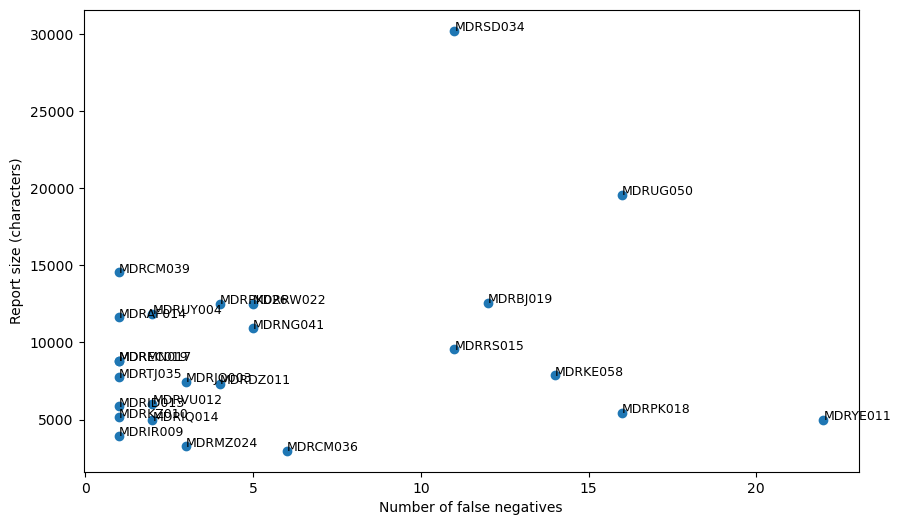

In [89]:
fig, ax = plt.subplots(figsize=(10, 6))
xkey = "appealCode"
ykey = "reportSize"
x = missed_df.groupby("appealCode")[xkey].count()
y = missed_df.groupby("appealCode").head(1).set_index("appealCode")[ykey]
plot_df = pd.DataFrame(
    {
        "x": x,
        "y": y,
    }
)

ax.plot(plot_df["x"], plot_df["y"], "o")

for appeal, row in plot_df.iterrows():
    ax.text(row["x"], row["y"], appeal, fontsize=9)

ax.set_xlabel("Number of false negatives")
ax.set_ylabel("Report size (characters)")

In [90]:
false_positives_df.appealCode.value_counts()

appealCode
MDRSD034    35
MDRUG050    24
MDRKE058    22
MDRRW022    17
MDRCO023    15
MDRYE011    12
MDRUY004    10
MDRBJ019    10
MDRPK018    10
MDRNG041     9
MDRDZ011     9
MDRZM022     8
MDRVU012     8
MDRAF014     8
MDRPH036     7
MDRPK026     7
MDRCM039     7
MDRRS015     6
MDRCM036     6
MDRIQ014     6
MDRIR009     5
MDRPG008     5
MDRMN017     5
MDRLB013     5
MDRTJ035     4
MDRBD022     4
MDRJO003     4
MDRS2001     4
MDRID013     3
MDREC019     3
MDRKZ010     3
MDRMZ024     2
MDRSV012     2
MDR55001     2
MDRGW003     1
MDRCN006     1
MDRDZ008     1
Name: count, dtype: int64

In [91]:
false_positives_df.groupby("appealCode").count()

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,valid_errors_impactValue,location,locationAnnotation,...,locationPolygon,iso3_code,gaul0_code,gaul1_code,gaul2_code,impactValueApprox,flag_pop_cntry,geometry,appealType,reportSize
appealCode,,,,,,,,,,,,,,,,,,,,,
MDR55001,2,0,0,0,0,2,2,2,2,2,...,2,2,2,2,2,0,2,2,0,0
MDRAF014,8,4,0,0,4,8,8,8,8,8,...,8,8,8,8,8,0,8,8,8,8
MDRBD022,4,2,0,0,2,4,4,4,4,4,...,4,4,4,4,4,0,4,4,0,0
MDRBJ019,10,4,0,0,4,10,10,10,10,10,...,10,10,10,10,10,0,10,10,10,10
MDRCM036,6,2,0,0,2,6,6,6,6,6,...,6,6,6,6,6,0,6,6,6,6
MDRCM039,7,1,0,0,1,7,7,7,7,7,...,7,7,7,7,7,0,7,7,7,7
MDRCN006,1,1,0,0,1,1,1,1,1,1,...,1,1,1,1,1,0,1,1,0,0
MDRCO023,15,4,0,0,4,15,15,15,15,15,...,15,15,15,15,15,0,15,15,0,0
MDRDZ008,1,1,0,0,1,1,1,1,1,1,...,1,1,1,1,1,0,1,1,0,0


Text(0, 0.5, 'Report size (characters)')

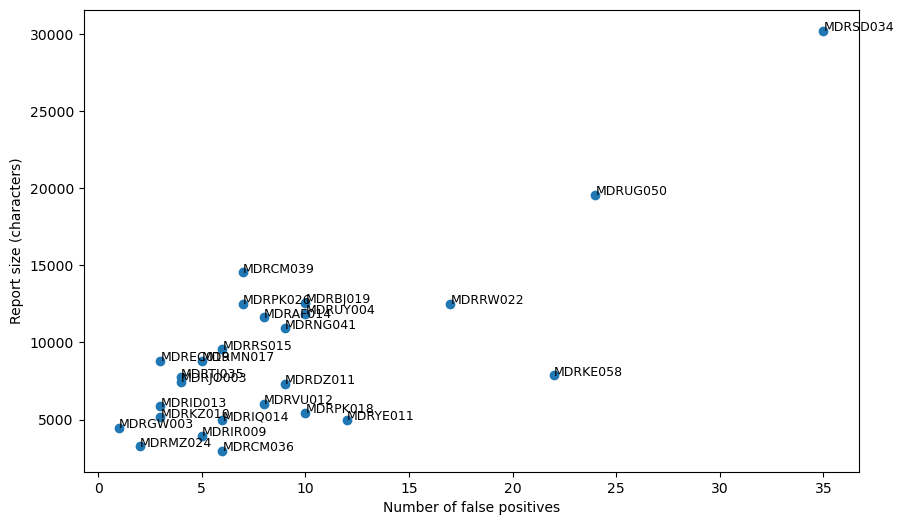

In [92]:
fig, ax = plt.subplots(figsize=(10, 6))
xkey = "appealCode"
ykey = "reportSize"
x = false_positives_df.groupby("appealCode")[xkey].count()
y = false_positives_df.groupby("appealCode").head(1).set_index("appealCode")[ykey]
plot_df = pd.DataFrame(
    {
        "x": x,
        "y": y,
    }
)

ax.plot(plot_df["x"], plot_df["y"], "o")

for appeal, row in plot_df.iterrows():
    ax.text(row["x"], row["y"], appeal, fontsize=9)

ax.set_xlabel("Number of false positives")
ax.set_ylabel("Report size (characters)")

/Users/lseverino/miniforge3/envs/ifrc_llm_311/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/Users/lseverino/miniforge3/envs/ifrc_llm_311/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


<Axes: title={'center': 'False positives and negatives by flag'}>

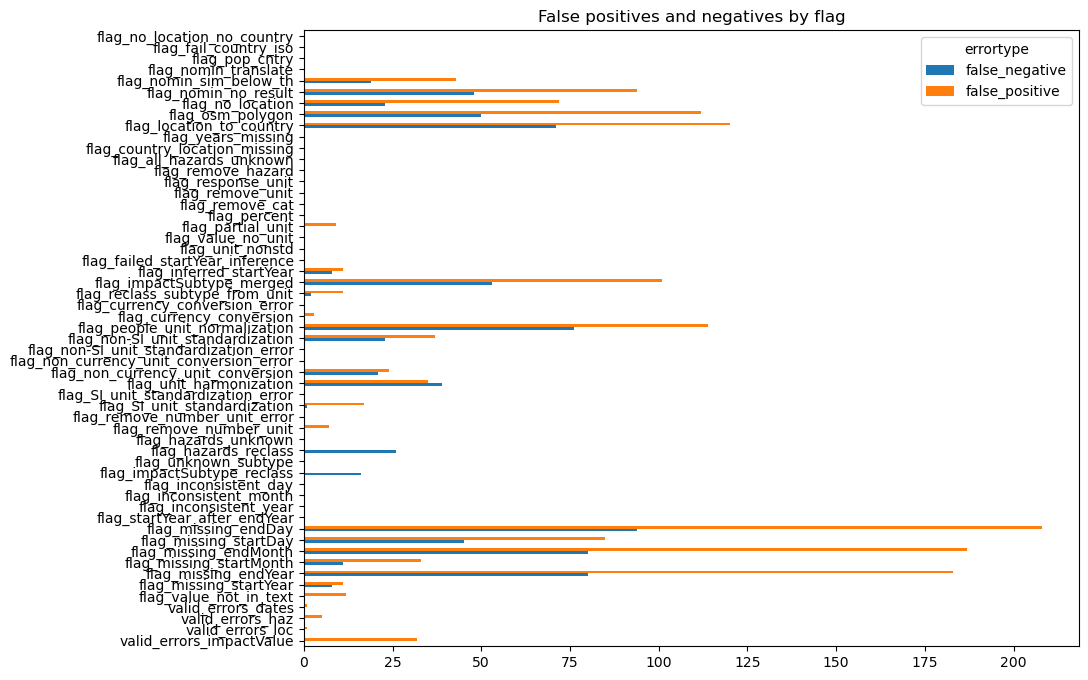

In [93]:
# flag analysis
false_positives_df["errortype"] = "false_positive"
missed_df["errortype"] = "false_negative"
false_and_missed = pd.concat([false_positives_df, missed_df], axis=0)
flag_cols = get_flag_cols(false_and_missed)
false_and_missed[flag_cols] = false_and_missed[flag_cols].map(lambda x: normalize_flags(x, output_type="int"))

counts = false_and_missed.groupby("errortype")[flag_cols].sum().T

counts.plot(
    kind="barh",
    figsize=(10, 8),
    title="False positives and negatives by flag",
)

In [94]:
flag_cols

['valid_errors_impactValue',
 'valid_errors_loc',
 'valid_errors_haz',
 'valid_errors_dates',
 'flag_value_not_in_text',
 'flag_missing_startYear',
 'flag_missing_endYear',
 'flag_missing_startMonth',
 'flag_missing_endMonth',
 'flag_missing_startDay',
 'flag_missing_endDay',
 'flag_startYear_after_endYear',
 'flag_inconsistent_year',
 'flag_inconsistent_month',
 'flag_inconsistent_day',
 'flag_impactSubtype_reclass',
 'flag_unknown_subtype',
 'flag_hazards_reclass',
 'flag_hazards_unknown',
 'flag_remove_number_unit',
 'flag_remove_number_unit_error',
 'flag_SI_unit_standardization',
 'flag_SI_unit_standardization_error',
 'flag_unit_harmonization',
 'flag_non_currency_unit_conversion',
 'flag_non_currency_unit_conversion_error',
 'flag_non-SI_unit_standardization_error',
 'flag_non-SI_unit_standardization',
 'flag_people_unit_normalization',
 'flag_currency_conversion',
 'flag_currency_conversion_error',
 'flag_reclass_subtype_from_unit',
 'flag_impactSubtype_merged',
 'flag_inferred

<Axes: title={'center': 'False positives and negatives by flag'}>

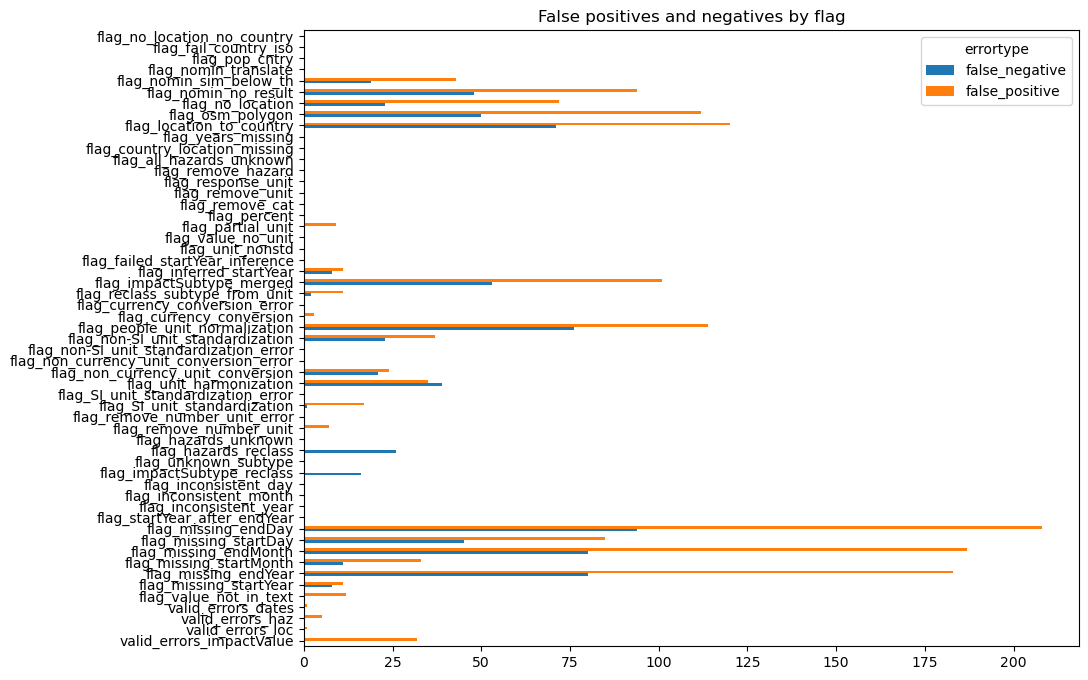

In [95]:
# flag analysis
flag_cols = get_flag_cols(false_and_missed)
false_and_missed[flag_cols] = false_and_missed[flag_cols].map(
    lambda x: normalize_flags(x, output_type="int")
)

counts = false_and_missed.groupby("errortype")[flag_cols].sum().T

counts.plot(
    kind="barh",
    figsize=(10, 8),
    title="False positives and negatives by flag",
)

In [96]:
false_positives_df.impactSubtype.value_counts()

impactSubtype
Affected People                                54
Agriculture and Access to Food                 32
Residential Buildings                          29
Water, Sanitation, and Hygiene                 28
Homeless People                                20
Human Health and Wellbeing                     18
Displaced People                               18
Economy and Livelihood                         16
Human Deaths                                   16
Transportation                                 15
Healthcare                                     14
Infected and Ill People                        10
Education                                       6
Informal Settlements                            5
Undefined Infrastructure and Service Access     3
Injured People                                  3
Power and Energy Production                     2
IT and Communication                            1
Name: count, dtype: int64

In [137]:
print_impact(extracted_df_filter[extracted_df_filter["flag_inconsistent_year"]==True])

,appealCode,impactSubtype,impactValue,impactUnit,location,locationPolygon,startYear,startMonth,startDay,endYear,endMonth,endDay,hazards,valueAnnotation,locationAnnotation,hazardsAnnotation,dateAnnotation


In [97]:
appeal = "MDRLB013"
print_match(matched_df_filter1[matched_df_filter1["appealCode"] == appeal])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,locationPolygon,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
267,MDRLB013,Affected People,Affected People,1024200.0,1024200.0,people,people,[],"['Bekaa', 'North']",[Lebanon],...,1.0,1.0,1.0,0.0,0.0,0.0,0.500000,0.940097,"[People Affected: 1,024,200 people]",['Appeal: Total DREF Allocation Crisis Categor...
268,MDRLB013,Affected People,Human Deaths,1024200.0,3.0,people,people,[],"['Bekaa Valley', 'Baalbek-Hermel']",[Lebanon],...,1.0,1.0,1.0,1.0,1.0,1.0,0.500000,0.438396,"[People Affected: 1,024,200 people]",['In the northern Bekaa Valley in Baalbek-Herm...
269,MDRLB013,Affected People,Affected People,NaN,NaN,null,null,"[Bekaa Valley, Beirut, Mount Lebanon, South re...","['Bekaa', 'Beirut', 'Mount Lebanon', 'South', ...","[Zahle, Beirut, Aley, Lebanon]",...,1.0,1.0,0.0,0.0,0.0,0.0,0.500000,0.846020,[Data from Interagency Coordination Lebanon in...,['Data from Interagency Coordination Lebanon i...
270,MDRLB013,Transportation,Education,NaN,NaN,null,null,"[Akkar, Bekaa Valley, North of the country, Mo...","['Bekaa', 'North']","[Lebanon, Baalbek-El Hermel, Zahle, Aley, Akkar]",...,1.0,1.0,0.0,1.0,1.0,0.0,0.577350,0.459060,[Many roads were closed for a week or longer d...,"['On 6 February, the weather deteriorated in t..."
271,MDRLB013,Transportation,Transportation,NaN,NaN,null,null,"[Akkar, Bekaa Valley, North of the country, Mo...",[],"[Lebanon, Baalbek-El Hermel, Zahle, Aley, Akkar]",...,1.0,1.0,0.0,1.0,1.0,1.0,0.577350,0.931938,[Many roads were closed for a week or longer d...,['Many roads were closed for a week or longer ...
272,MDRLB013,Transportation,Transportation,NaN,NaN,null,null,"[Akkar, Bekaa Valley, North of the country, Mo...",[],"[Lebanon, Baalbek-El Hermel, Zahle, Aley, Akkar]",...,1.0,1.0,0.0,0.0,0.0,0.0,0.577350,0.848605,[Many roads were closed for a week or longer d...,['The area was also affected by the closure of...
273,MDRLB013,Transportation,Transportation,NaN,NaN,null,null,"[Akkar, Bekaa Valley, North of the country, Mo...",[],"[Lebanon, Baalbek-El Hermel, Zahle, Aley, Akkar]",...,1.0,1.0,0.0,0.0,0.0,0.0,0.816497,0.868534,[Many roads were closed for a week or longer d...,['These conditions have left communities isola...
274,MDRLB013,Agriculture and Access to Food,Undefined Infrastructure and Service Access,NaN,NaN,null,null,"[Akkar governorate, Bekaa Valley, Baalbek-Herm...",['Kebir River'],"[Lebanon, Baalbek-El Hermel, Zahle, Beirut, Al...",...,1.0,1.0,0.0,1.0,1.0,1.0,0.577350,0.487218,[Movement for residents of ITS has been severe...,"['At lower altitudes in the same governorate, ..."
275,MDRLB013,Agriculture and Access to Food,Undefined Infrastructure and Service Access,NaN,NaN,null,null,"[Akkar governorate, Bekaa Valley, Baalbek-Herm...",['Litani River'],"[Lebanon, Baalbek-El Hermel, Zahle, Beirut, Al...",...,1.0,1.0,0.0,1.0,1.0,1.0,0.577350,0.306125,[Movement for residents of ITS has been severe...,"['Flooding occurred at multiple sites, with an..."
276,MDRLB013,Agriculture and Access to Food,Power and Energy Production,NaN,NaN,null,null,"[Akkar governorate, Bekaa Valley, Baalbek-Herm...",[],"[Lebanon, Baalbek-El Hermel, Zahle, Beirut, Al...",...,1.0,1.0,0.0,1.0,1.0,1.0,0.816497,0.507147,[Movement for residents of ITS has been severe...,['Movement for residents of ITS has been sever...


In [98]:
print_match(matched_df_filter2[matched_df_filter2["appealCode"] == appeal])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,locationPolygon,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
267,MDRLB013,Affected People,Affected People,1024200.0,1024200.0,people,people,[],"['Bekaa', 'North']",[Lebanon],...,1.0,1.0,1.0,0.0,0.0,0.0,0.500000,0.940097,"[People Affected: 1,024,200 people]",['Appeal: Total DREF Allocation Crisis Categor...
269,MDRLB013,Affected People,Affected People,NaN,NaN,null,null,"[Bekaa Valley, Beirut, Mount Lebanon, South re...","['Bekaa', 'Beirut', 'Mount Lebanon', 'South', ...","[Zahle, Beirut, Aley, Lebanon]",...,1.0,1.0,0.0,0.0,0.0,0.0,0.500000,0.846020,[Data from Interagency Coordination Lebanon in...,['Data from Interagency Coordination Lebanon i...
271,MDRLB013,Transportation,Transportation,NaN,NaN,null,null,"[Akkar, Bekaa Valley, North of the country, Mo...",[],"[Lebanon, Baalbek-El Hermel, Zahle, Aley, Akkar]",...,1.0,1.0,0.0,1.0,1.0,1.0,0.577350,0.931938,[Many roads were closed for a week or longer d...,['Many roads were closed for a week or longer ...
272,MDRLB013,Transportation,Transportation,NaN,NaN,null,null,"[Akkar, Bekaa Valley, North of the country, Mo...",[],"[Lebanon, Baalbek-El Hermel, Zahle, Aley, Akkar]",...,1.0,1.0,0.0,0.0,0.0,0.0,0.577350,0.848605,[Many roads were closed for a week or longer d...,['The area was also affected by the closure of...
273,MDRLB013,Transportation,Transportation,NaN,NaN,null,null,"[Akkar, Bekaa Valley, North of the country, Mo...",[],"[Lebanon, Baalbek-El Hermel, Zahle, Aley, Akkar]",...,1.0,1.0,0.0,0.0,0.0,0.0,0.816497,0.868534,[Many roads were closed for a week or longer d...,['These conditions have left communities isola...
277,MDRLB013,Agriculture and Access to Food,Agriculture and Access to Food,NaN,NaN,null,null,"[Akkar governorate, Bekaa Valley, Baalbek-Herm...",[],"[Lebanon, Baalbek-El Hermel, Zahle, Beirut, Al...",...,1.0,1.0,0.0,1.0,1.0,1.0,0.816497,0.951591,[Movement for residents of ITS has been severe...,['Movement for residents of ITS has been sever...
278,MDRLB013,"Water, Sanitation, and Hygiene","Water, Sanitation, and Hygiene",NaN,NaN,null,null,"[Akkar, Bekaa Valley, Baalbek-Hermel governora...",[],"[Baalbek-El Hermel, Zahle, Beirut, Aley, Akkar...",...,1.0,0.0,0.0,0.0,0.0,0.0,0.707107,0.831364,[Movement for residents of ITS has been severe...,['Movement for residents of ITS has been sever...


In [99]:
print_impact(false_positives_df[false_positives_df["appealCode"] == appeal])

,appealCode,impactSubtype,impactValue,impactUnit,location,locationPolygon,startYear,startMonth,startDay,endYear,endMonth,endDay,hazards,valueAnnotation,locationAnnotation,hazardsAnnotation,dateAnnotation
788,MDRLB013,Informal Settlements,22.0,informal settlements,[],[Lebanon],2022.0,NaN,NaN,NaN,NaN,NaN,"[Flood, Extreme cold temperature, Convective s...",[They pose additional risks to those living in...,[They pose additional risks to those living in...,"[In February 2023, Lebanon has been hit by a w...",[They pose additional risks to those living in...
791,MDRLB013,Transportation,NaN,null,"[Akkar, Bekaa Valley, Beirut, Mount Lebanon, S...","[Baalbek-El Hermel, Zahle, Beirut, Aley, Akkar...",2023.0,1.0,31.0,2023.0,2.0,14.0,"[Flood, Extreme cold temperature, Other storm]",[These conditions have left communities isolat...,[In Lebanon’s northernmost governorate of Akka...,[In Lebanon’s northernmost governorate of Akka...,[Winter storm Farah hit Lebanon on 31 January ...
794,MDRLB013,Human Health and Wellbeing,NaN,null,"[Akkar, Baalbek-Hermel, Bekaa Valley, Beirut, ...","[Zahle, Beirut, Aley, Akkar, Baalbek-El Hermel...",2023.0,1.0,31.0,2023.0,2.0,14.0,"[Flood, Extreme cold temperature, Convective s...",[This comes as Lebanon is attempting to recove...,[In Lebanon’s northernmost governorate of Akka...,[In the northern Bekaa Valley in Baalbek-Herme...,[Winter storm Farah hit Lebanon on 31 January ...
795,MDRLB013,Healthcare,NaN,null,"[Bekaa Valley, Beirut, Mount Lebanon, South an...","[Baalbek-El Hermel, Zahle, Beirut, Aley, Akkar...",2022.0,12.0,NaN,NaN,NaN,NaN,"[Flood, Extreme cold temperature, Convective s...",[This comes as Lebanon is attempting to recove...,[Data from Interagency Coordination Lebanon in...,[In Lebanon’s northernmost governorate of Akka...,[This comes as Lebanon is attempting to recove...
796,MDRLB013,Economy and Livelihood,NaN,null,"[Akkar, Baalbek-Hermel, Bekaa Valley, Beirut, ...","[Zahle, Beirut, Aley, Akkar, Baalbek-El Hermel...",2023.0,1.0,31.0,2023.0,2.0,14.0,"[Flood, Extreme cold temperature, Other storm]",[Akkar and Baalbek-Hermel governorates were id...,[In Lebanon’s northernmost governorate of Akka...,[In Lebanon’s northernmost governorate of Akka...,[Winter storm Farah hit Lebanon on 31 January ...


In [100]:
print_impact(missed_df[missed_df["appealCode"] == appeal])

,appealCode,impactSubtype,impactValue,impactUnit,location,locationPolygon,startYear,startMonth,startDay,endYear,endMonth,endDay,hazards,annotation
722,MDRLB013,Education,NaN,null,"[Bekaa, North]","[Bekaa, Lebanon]",2023.0,2.0,6.0,2023.0,2.0,9.0,[Extreme cold temperature],"[On 6 February, the weather deteriorated in th..."
726,MDRLB013,Undefined Infrastructure and Service Access,NaN,null,[Kebir River],[Lebanon],2023.0,2.0,21.0,NaN,NaN,NaN,[Flood],"[At lower altitudes in the same governorate, h..."
727,MDRLB013,Undefined Infrastructure and Service Access,NaN,null,[Litani River],[West Bekaa],2023.0,2.0,21.0,NaN,NaN,NaN,[Flood],"[Flooding occurred at multiple sites, with an ..."
728,MDRLB013,Human Deaths,3.0,people,"[Bekaa Valley, Baalbek-Hermel]","[Zahle, Baalbek-El Hermel]",2023.0,2.0,21.0,NaN,NaN,NaN,[Flood],[In the northern Bekaa Valley in Baalbek-Herme...
731,MDRLB013,Power and Energy Production,NaN,null,[],[Lebanon],2023.0,2.0,21.0,NaN,NaN,NaN,"[Extreme cold temperature, Flood]",[Movement for residents of ITS has been severe...


In [101]:
false_positives_df.columns

Index(['impactSubtype', 'impactValue', 'impactValueMin', 'impactValueMax',
       'impactValuePrecision', 'impactUnit', 'valueAnnotation',
       'valid_errors_impactValue', 'location', 'locationAnnotation',
       'valid_errors_loc', 'hazards', 'hazardsAnnotation', 'valid_errors_haz',
       'startYear', 'startMonth', 'startDay', 'endYear', 'endMonth', 'endDay',
       'dateAnnotation', 'valid_errors_dates', 'appealCode', 'reportDate',
       'reportLink', 'disasterType', 'nathaz_text', 'quanti',
       'flag_value_not_in_text', 'flag_missing_startYear',
       'flag_missing_endYear', 'flag_missing_startMonth',
       'flag_missing_endMonth', 'flag_missing_startDay', 'flag_missing_endDay',
       'flag_startYear_after_endYear', 'flag_inconsistent_year',
       'flag_inconsistent_month', 'flag_inconsistent_day',
       'flag_impactSubtype_reclass', 'flag_unknown_subtype',
       'flag_hazards_reclass', 'flag_hazards_unknown',
       'flag_remove_number_unit', 'flag_remove_number_unit_e

In [102]:
false_positives_df[false_positives_df["appealCode"] == "MDRSD034"][["country_robust", "location", "locationPolygon"]]

,country_robust,location,locationPolygon
215,['Sudan'],[17 states],[Khartoum]
218,['Sudan'],[],[Sudan]
219,['Sudan'],[15 states],[Sharg An Neel]
222,['Sudan'],[],[Sudan]
225,['Sudan'],"[Northern States, River Nile State]","[Northern, Baw]"
229,['Sudan'],"[Northern State, Gold locality]","[Northern, Sudan]"
233,['Sudan'],[],[Sudan]
236,['Sudan'],"[Atbara-Abu Hamad Road, Dongola-Halfa Road, Su...","[Sudan, Northern]"
237,['Sudan'],"[Atbara, Abu Hamad, Dongola, Halfa, Abu Sara]","[Reifi Nahr Atbara, Atbara, Abu Hamad, Dongola..."
240,['Sudan'],[],[Sudan]


In [103]:
print_impact(missed_df[missed_df["appealCode"] == "MDRSD034"])

,appealCode,impactSubtype,impactValue,impactUnit,location,locationPolygon,startYear,startMonth,startDay,endYear,endMonth,endDay,hazards,annotation
507,MDRSD034,Undefined Infrastructure and Service Access,NaN,null,[Arbaat Dam],[Sudan],2024.0,8.0,25.0,NaN,NaN,NaN,[Flood],"[In total, 119 incidents of heavy rain were re..."
508,MDRSD034,Human Deaths,30.0,people,[Arbaat Dam],[Sudan],2024.0,8.0,25.0,NaN,NaN,NaN,[Flood],"[In total, 119 incidents of heavy rain were re..."
526,MDRSD034,Residential Buildings,2000.0,homes,[Gold Locality],[Sudan],2024.0,4.0,NaN,2024.0,10.0,NaN,[Flood],"[On 25 August 2024, heavy rains led to widespr..."
528,MDRSD034,Residential Buildings,8016.0,homes,[Abu Hamad locality],[Abu Hamad],2024.0,4.0,NaN,2024.0,10.0,NaN,[Flood],"[On 25 August 2024, heavy rains led to widespr..."
529,MDRSD034,Human Deaths,34.0,people,[River Nile State],[Baw],2024.0,4.0,NaN,2024.0,10.0,NaN,[Flood],"[On 25 August 2024, heavy rains led to widespr..."
558,MDRSD034,Infected and Ill People,11014.0,people,[White Nile],[White Nile],2024.0,NaN,NaN,2025.0,3.0,10.0,"[Epidemic, Flood]",[The cumulative cases jumped from 2895 cases (...
559,MDRSD034,Infected and Ill People,11014.0,people,[Gazira],[Sudan],2024.0,NaN,NaN,2025.0,3.0,10.0,"[Epidemic, Flood]",[The cumulative cases jumped from 2895 cases (...
561,MDRSD034,Infected and Ill People,7444.0,people,[Kassala],[Kassala],2024.0,NaN,NaN,2025.0,3.0,10.0,"[Epidemic, Flood]",[The cumulative cases jumped from 2895 cases (...
562,MDRSD034,Infected and Ill People,6123.0,people,[River Nile state],[Baw],2024.0,NaN,NaN,2025.0,3.0,10.0,"[Epidemic, Flood]",[The cumulative cases jumped from 2895 cases (...
563,MDRSD034,Infected and Ill People,10827.0,people,[White Nile state],[White Nile],2024.0,NaN,NaN,2025.0,3.0,3.0,"[Epidemic, Flood]",[The cumulative cases jumped from 2895 cases (...


In [104]:
print(extracted_df_filter[
    (extracted_df_filter["appealCode"] == "MDRYE011")
    # & (extracted_df["impactSubtype"] == "Affected People")
]["nathaz_text"].values[0])

["P a g e | 1 Emergency Plan of Action (EPoA) Yemen: Sanaa Floods DREF Operation n° MDRYE011 Glide n°: FL-2022-000265-YEM Date of issue: 29/07/2022 Expected timeframe: 6 months Expected end date: 31/01/2023 Category allocated to the of the disaster or crisis: Orange DREF allocated: CHF 452,156 Total number of people affected: Approximately 76,790 Number of people to 19,509 people (2,787 HH) be assisted: people affected Governorates affected: Marib, Al Mahwit, Governorates targeted: Al Hodeida, Hajjah Taiz, Ibb, Hadramout, and Al- Hadramawt, Al Mahra, Marib and Sana’a Bayda, Amran, Governorates Sadaa, Dhamar Al Hodeida Sana'a Hajjah, Al Mahra governorates Operating National Society: Yemen Red Crescent Society has branches in all 22 Governates of Yemen, with 321 staff and 4,500 active volunteers, including 44 National Disaster Response trained team members, as well as trained first aid volunteers ready to deploy in case of emergency.", 'Red Cross Red Crescent Movement partners: British R

In [105]:
extracted_df_filter[extracted_df_filter["quanti"]=="quali"]["startYear"].value_counts(dropna=False).T

startYear
2024.0    112
2023.0     69
2022.0     23
2021.0     12
2018.0     10
2019.0      6
2020.0      6
2016.0      3
1992.0      1
1985.0      1
Name: count, dtype: int64

In [106]:
print_impact(
    extracted_df_filter[
        (extracted_df_filter["appealCode"] == "MDRSD034")
        #& (extracted_df["impactSubtype"] == "Affected People")
    ]
)

,appealCode,impactSubtype,impactValue,impactUnit,location,locationPolygon,startYear,startMonth,startDay,endYear,endMonth,endDay,hazards,valueAnnotation,locationAnnotation,hazardsAnnotation,dateAnnotation
212,MDRSD034,Affected People,460743.0,people,[],[Sudan],2024.0,8.0,25.0,NaN,NaN,NaN,"[Flood, Conflict]","[People Affected: 460,743 people]","[People Affected: 460,743 people]","[On 25 August 2024, heavy rains led to widespr...","[On 25 August 2024, heavy rains led to widespr..."
215,MDRSD034,Affected People,696000.0,people,[17 states],[Khartoum],2025.0,3.0,NaN,NaN,NaN,NaN,"[Flood, Epidemic, Conflict]",[The situation led to with widespread floods a...,[The situation led to with widespread floods a...,"[On 25 August 2024, heavy rains led to widespr...",[There was a notable increase in number of peo...
216,MDRSD034,Affected People,24800000.0,people,[],[Sudan],2023.0,4.0,NaN,NaN,NaN,NaN,"[Flood, Epidemic, Conflict]",[The dual crises of flooding and cholera outbr...,[The dual crises of flooding and cholera outbr...,[The dual crises of flooding and cholera outbr...,[The dual crises of flooding and cholera outbr...
217,MDRSD034,Displaced People,10000000.0,people,[],[Sudan],2023.0,4.0,NaN,NaN,NaN,NaN,"[Flood, Epidemic, Conflict]",[The dual crises of flooding and cholera outbr...,[The dual crises of flooding and cholera outbr...,[The dual crises of flooding and cholera outbr...,[The dual crises of flooding and cholera outbr...
218,MDRSD034,Healthcare,80.0,healthcare structures,[],[Sudan],2023.0,4.0,NaN,NaN,NaN,NaN,"[Conflict, Flood, Epidemic]",[The conflict disrupted the operations of 80% ...,[The conflict disrupted the operations of 80% ...,[The conflict disrupted the operations of 80% ...,[The conflict disrupted the operations of 80% ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
316,MDRSD034,"Water, Sanitation, and Hygiene",NaN,null,"[Tokar, Port Sudan, Khor Baraka, Khor Arab, Ar...","[Baw, Northern, Red Sea, Tawkar, Sudan, West D...",2024.0,8.0,25.0,NaN,NaN,NaN,"[Flood, Epidemic]",[unsafe drinking water],"[The catastrophic collapse of the Arba’at Dam,...","[The catastrophic collapse of the Arba’at Dam,...","[On August 25, the catastrophic collapse of th..."
318,MDRSD034,Homeless People,NaN,null,"[Tokar, Atbara-Abu Hamad Road, Dongola-Halfa R...","[Kassala, Baw, Northern, Sudan, Abu Hamad, Whi...",2024.0,7.0,NaN,2025.0,3.0,10.0,"[Flood, Epidemic, Conflict]",[These basic necessities will offer comfort an...,[Residents have described the situation in Tok...,"[On 25 August 2024, heavy rains led to widespr...","[The floods resulted on 64 fatalities, 1,246 i..."
319,MDRSD034,Transportation,NaN,null,"[Atbara-Abu Hamad Road, Dongola-Halfa Road, Su...","[Northern, Sudan, Abu Hamad, Red Sea, Al Mafaz...",2024.0,8.0,25.0,NaN,NaN,NaN,[Flood],[Flooding from Khor Arab and Khor Baraka furth...,"[In Northern state, SRCS rapid assessments in ...","[On August 25, the catastrophic collapse of th...","[On August 25, the catastrophic collapse of th..."
320,MDRSD034,Economy and Livelihood,NaN,null,"[Tokar, Port Sudan, Aqeeq, Khor Baraka, Khor A...","[Gedaref, Kassala, Baw, Northern, Sudan, South...",2023.0,4.0,NaN,NaN,NaN,NaN,"[Flood, Epidemic, Conflict]",[This therefore calls for the SRCS to support ...,[The waters of Khor Baraka surging in a 6-mete...,"[On 25 August 2024, heavy rains led to widespr...",[the conflict that began in April 2023]


In [107]:
extracted_df_filter

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,valid_errors_impactValue,location,locationAnnotation,...,locationPolygon,iso3_code,gaul0_code,gaul1_code,gaul2_code,impactValueApprox,flag_pop_cntry,geometry,appealType,reportSize
0,Affected People,2176519.0,NaN,NaN,exact,people,"[Total number of people affected: 2,176,519]",0,[],"[Total number of people affected: 2,176,519]",...,[Bangladesh],[BGD],[229.0],[None],[None],NaN,False,"MULTIPOLYGON (((88.97148 22.51094, 88.9207 22....",NaN,NaN
3,Displaced People,31818.0,NaN,NaN,exact,people,"[of people who have moved to safe shelter 31,818]",0,[],"[of people who have moved to safe shelter 31,818]",...,[Bangladesh],[BGD],[229.0],[None],[None],NaN,False,"MULTIPOLYGON (((88.97148 22.51094, 88.9207 22....",NaN,NaN
4,Residential Buildings,3988.0,NaN,NaN,exact,homes,"[of fully damaged house 3,988]",0,[],"[No. of fully damaged house 3,988]",...,[Bangladesh],[BGD],[229.0],[None],[None],NaN,False,"MULTIPOLYGON (((88.97148 22.51094, 88.9207 22....",NaN,NaN
5,Residential Buildings,98571.0,NaN,NaN,exact,homes,"[of partially damaged house 98,571]",0,[],"[of partially damaged house 98,571]",...,[Bangladesh],[BGD],[229.0],[None],[None],NaN,False,"MULTIPOLYGON (((88.97148 22.51094, 88.9207 22....",NaN,NaN
7,Affected People,2100000.0,NaN,NaN,exact,people,[According to National disaster response coord...,0,[21 districts],[According to National disaster response coord...,...,[Dhaka],[BGD],[229.0],[2474],[124259],NaN,False,"MULTIPOLYGON (((90.18576 23.56293, 90.18114 23...",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
974,Human Health and Wellbeing,NaN,NaN,NaN,None,null,[BBC news reported that the snowfall in these ...,1,"[Azad Jammu and Kashmir (AJK), Balochistan, Kh...","[In January 2020, several parts of Pakistan we...",...,"[Balochistan, Jaffarabad, Khyber Pakhtunkhwa, ...",[PAK],[260.0],"[2905, 2907, None]","[None, 130104, 130130, 130103, 130112, 130122,...",NaN,False,"MULTIPOLYGON (((69.854 32.09808, 69.85255 32.0...",DREF Operation Final Report,5417.0
975,Transportation,NaN,NaN,NaN,None,null,[Gilgit Baltistan authorities mobilized all th...,0,"[Azad Jammu and Kashmir (AJK), Balochistan, Kh...","[In January 2020, several parts of Pakistan we...",...,"[Balochistan, Jaffarabad, Khyber Pakhtunkhwa, ...",[PAK],[260.0],"[2905, 2907, None, 2909]","[None, 130104, 130206, 130130, 130103, 130112,...",NaN,False,"MULTIPOLYGON (((69.854 32.09808, 69.85255 32.0...",DREF Operation Final Report,5417.0
976,Affected People,2282.0,NaN,NaN,exact,people,[Number of people affected: up to approximatel...,0,[Szabolcs-Szatmár-Bereg County],"[On 21 June 2016, heavy rain and hailstorm hit...",...,[Szabolcs Szatmar Bereg],[HUN],[308.0],[3509],[None],NaN,False,"MULTIPOLYGON (((22.23993 48.40959, 22.24112 48...",DREF Operation Final Report,1736.0
978,Residential Buildings,750.0,NaN,NaN,exact,homes,[It was reported by the National Directorate G...,1,[Szabolcs-Szatmár-Bereg County],"[On 21 June 2016, heavy rain and hailstorm hit...",...,[Szabolcs Szatmar Bereg],[HUN],[308.0],[3509],[None],NaN,False,"MULTIPOLYGON (((22.23993 48.40959, 22.24112 48...",DREF Operation Final Report,1736.0


In [108]:
false_positives_df.value_counts("quanti")

quanti
quanti    173
quali     117
Name: count, dtype: int64

In [109]:
from src.data_format import listify_strings


hazs = labelled_df_filter.hazards.apply(listify_strings)
hazs.explode().nunique()

13

In [110]:

nboots = 5000
df_list = []
for qq in ["all", "quanti", "quali"]:
    if qq == "all":
        labelled_dfq = labelled_df_filter
        extracted_dfq = extracted_df_filter
        matched_df_filterq = matched_df_filter2
    else:
        labelled_dfq = labelled_df_filter[labelled_df_filter["quanti"]==qq]
        extracted_dfq = extracted_df_filter[extracted_df_filter["quanti"]==qq]
        matched_df_filterq = matched_df_filter2[matched_df_filter2["quanti"]==qq]
    n_ext = len(extracted_dfq)
    n_lab = len(labelled_dfq)
    tps = true_positives(matched_df_filterq)
    fps = false_positives(n_ext, tps)
    fns = false_negatives(n_lab, tps)
    precisions = precision_bt(tps, fps)
    recalls = recall_bt(tps, fns)
    f1s = f1_bt(tps, fps, fns)
    bs_metric_dict = bootstrap_f1(tps, fps, fns, n_boot=nboots)
    dict_res = {
            "quanti" : qq,
            "n_ext": n_ext,
            "n_lab": n_lab,
            "tps": tps,
            "fps": fps,
            "fns": fns,
            "f1": f1s,
            "precision": precisions,
            "recall": recalls,
            "f1_low_err": f1s - bs_metric_dict["f1_score"][0],
            "f1_high_err": bs_metric_dict["f1_score"][1] - f1s,
            "precision_low_err": precisions - bs_metric_dict["precision"][0],
            "precision_high_err": bs_metric_dict["precision"][1] - precisions,
            "recall_low_err": recalls - bs_metric_dict["recall"][0],
            "recall_high_err": bs_metric_dict["recall"][1] - recalls

    }
    df_list.append(pd.DataFrame(dict_res, index=[0]))

f1_bs_all = pd.concat(df_list)



In [111]:
f1_bs_all[["quanti","f1", "precision", "recall"]]

,quanti,f1,precision,recall
0,all,0.727782,0.704607,0.752533
0,quanti,0.702815,0.680808,0.726293
0,quali,0.812766,0.786008,0.841410


In [112]:
group_keys = IMPACT_SUBTYPES_MERGED
group_key = "impactSubtype"
nboots = 5000
df_list = []
for group_id in group_keys:
    group_lab = labelled_df_filter[labelled_df_filter[group_key] == group_id]
    group_ext = extracted_df_filter[extracted_df_filter[group_key] == group_id]
    group_ext_match = matched_df_filter2[matched_df_filter2[group_key] == group_id]
    n_lab = len(group_lab)
    n_ext = len(group_ext)
    tps = true_positives(group_ext_match)
    fps = false_positives(n_ext, tps)
    fns = false_negatives(n_lab, tps)
    precisions = precision_bt(tps, fps)
    recalls = recall_bt(tps, fns)
    f1s = f1_bt(tps, fps, fns)
    bs_metric_dict = bootstrap_f1(tps, fps, fns, n_boot=nboots)
    bs_metric_dict = bootstrap_f1(tps, fps, fns, n_boot=nboots)
    dict_res = {
        "tps": tps,
        "n_ext": n_ext,
        "n_lab": n_lab,
        "tps": tps,
        "fps": fps,
        "fns": fns,
        "f1": f1s,
        "precision": precisions,
        "recall": recalls,
        "f1_low_err": f1s - bs_metric_dict["f1_score"][0],
        "f1_high_err": bs_metric_dict["f1_score"][1] - f1s,
        "precision_low_err": precisions - bs_metric_dict["precision"][0],
        "precision_high_err": bs_metric_dict["precision"][1] - precisions,
        "recall_low_err": recalls - bs_metric_dict["recall"][0],
        "recall_high_err": bs_metric_dict["recall"][1] - recalls,
    }
    df_list.append(pd.DataFrame(dict_res, index=[group_id]))
f1_bs_by_subtype = pd.concat(df_list).reset_index(drop=False, names=[group_key])

In [113]:
from src.impact_def import IMPACT_TYPES_MERGED

labelled_df_filter["impactType"] = labelled_df_filter["impactSubtype"].map(
    IMPACT_TYPES_MERGED
)
extracted_df_filter["impactType"] = extracted_df_filter["impactSubtype"].map(
    IMPACT_TYPES_MERGED
)
matched_df_filter2["impactType"] = matched_df_filter2["impactSubtype"].map(
    IMPACT_TYPES_MERGED
)
group_keys = pd.unique(IMPACT_TYPES_MERGED.values())
group_key = "impactType"
nboots = 5000
df_list = []
for group_id in group_keys:
    group_lab = labelled_df_filter[labelled_df_filter[group_key] == group_id]
    group_ext = extracted_df_filter[extracted_df_filter[group_key] == group_id]
    group_ext_match = matched_df_filter2[matched_df_filter2[group_key] == group_id]
    n_lab = len(group_lab)
    n_ext = len(group_ext)
    tps = true_positives(group_ext_match)
    fps = false_positives(n_ext, tps)
    fns = false_negatives(n_lab, tps)
    precisions = precision_bt(tps, fps)
    recalls = recall_bt(tps, fns)
    f1s = f1_bt(tps, fps, fns)
    bs_metric_dict = bootstrap_f1(tps, fps, fns, n_boot=nboots)
    bs_metric_dict = bootstrap_f1(tps, fps, fns, n_boot=nboots)
    dict_res = {
        "tps": tps,
        "n_ext": n_ext,
        "n_lab": n_lab,
        "tps": tps,
        "fps": fps,
        "fns": fns,
        "f1": f1s,
        "precision": precisions,
        "recall": recalls,
        "f1_low_err": f1s - bs_metric_dict["f1_score"][0],
        "f1_high_err": bs_metric_dict["f1_score"][1] - f1s,
        "precision_low_err": precisions - bs_metric_dict["precision"][0],
        "precision_high_err": bs_metric_dict["precision"][1] - precisions,
        "recall_low_err": recalls - bs_metric_dict["recall"][0],
        "recall_high_err": bs_metric_dict["recall"][1] - recalls,
    }
    df_list.append(pd.DataFrame(dict_res, index=[group_id]))
f1_bs_by_maintype = pd.concat(df_list).reset_index(drop=False, names=[group_key])
# append the total column
tot_col = f1_bs_all[f1_bs_all["quanti"] == "Total"].copy().rename(columns={"quanti": group_key})
f1_bs_by_maintype = pd.concat([tot_col, f1_bs_by_maintype]).reset_index(drop=True)

/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_49054/654541244.py:12: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  group_keys = pd.unique(IMPACT_TYPES_MERGED.values())


In [114]:
f1_bs_by_maintype

,impactType,n_ext,n_lab,tps,fps,fns,f1,precision,recall,f1_low_err,f1_high_err,precision_low_err,precision_high_err,recall_low_err,recall_high_err
0,Human,353,306,233,120,73,0.707132,0.660057,0.761438,0.040465,0.038082,0.047816,0.049706,0.049520,0.046254
1,Infrastructure and Service access,349,349,259,90,90,0.742120,0.742120,0.742120,0.037106,0.035038,0.046854,0.044012,0.046101,0.044624
2,Economy & Culture,36,36,28,8,8,0.777778,0.777778,0.777778,0.111111,0.094017,0.136752,0.128472,0.146199,0.133987


In [115]:
f1_bs_by_maintype

,impactType,n_ext,n_lab,tps,fps,fns,f1,precision,recall,f1_low_err,f1_high_err,precision_low_err,precision_high_err,recall_low_err,recall_high_err
0,Human,353,306,233,120,73,0.707132,0.660057,0.761438,0.040465,0.038082,0.047816,0.049706,0.049520,0.046254
1,Infrastructure and Service access,349,349,259,90,90,0.742120,0.742120,0.742120,0.037106,0.035038,0.046854,0.044012,0.046101,0.044624
2,Economy & Culture,36,36,28,8,8,0.777778,0.777778,0.777778,0.111111,0.094017,0.136752,0.128472,0.146199,0.133987


In [116]:
group_keys = labelled_df.appealCode.unique()
group_key = "appealCode"
nboots = 5000
df_list = []
for group_id in group_keys:
    group_lab = labelled_df_filter[labelled_df_filter[group_key] == group_id]
    group_ext = extracted_df_filter[extracted_df_filter[group_key] == group_id]
    group_ext_match = matched_df_filter2[matched_df_filter2[group_key] == group_id]
    n_lab = len(group_lab)
    n_ext = len(group_ext)
    tps = true_positives(group_ext_match)
    fps = false_positives(n_ext, tps)
    fns = false_negatives(n_lab, tps)
    precisions = precision_bt(tps, fps)
    recalls = recall_bt(tps, fns)
    f1s = f1_bt(tps, fps, fns)
    bs_metric_dict = bootstrap_f1(tps, fps, fns, n_boot=nboots)
    bs_metric_dict = bootstrap_f1(tps, fps, fns, n_boot=nboots)
    dict_res = {
        "tps": tps,
        "n_ext": n_ext,
        "n_lab": n_lab,
        "tps": tps,
        "fps": fps,
        "fns": fns,
        "f1": f1s,
        "precision": precisions,
        "recall": recalls,
        "f1_low_err": f1s - bs_metric_dict["f1_score"][0],
        "f1_high_err": bs_metric_dict["f1_score"][1] - f1s,
        "precision_low_err": precisions - bs_metric_dict["precision"][0],
        "precision_high_err": bs_metric_dict["precision"][1] - precisions,
        "recall_low_err": recalls - bs_metric_dict["recall"][0],
        "recall_high_err": bs_metric_dict["recall"][1] - recalls,
    }
    df_list.append(pd.DataFrame(dict_res, index=[group_id]))
f1_bs_by_appeal = pd.concat(df_list).reset_index(drop=False, names=[group_key])

In [117]:
# prepare data for plots
drop_appeals = []
f1_bs_all["quanti"].replace("quanti", "Quantitative", inplace=True)
f1_bs_all["quanti"].replace("quali", "Qualitative", inplace=True)
f1_bs_all["quanti"].replace("all", "Total", inplace=True)

# f1_bs_all.set_index("quanti", drop=True, inplace=True)
# f1_bs_all.replace(np.nan, 0, inplace=True)
# f1_bs_by_key.replace(np.nan, 0, inplace=True)
f1_bs_by_appeal = f1_bs_by_appeal.loc[
    ~f1_bs_by_appeal["appealCode"].isin(drop_appeals)
]
f1_bs_by_appeal = f1_bs_by_appeal.sort_values(by="tps", ascending=False)

# add report length and type to f1_bs_by_appeal
# f1_bs_by_appeal = f1_bs_by_appeal.merge(extracted_df_filter[["appealCode", "reportSize", "appealType"]].drop_duplicates(), how="left", on="appealCode")

/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_49054/725265483.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  f1_bs_all["quanti"].replace("quanti", "Quantitative", inplace=True)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_49054/725265483.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are se

In [118]:
#prepare data for plots
relab_dict = {"Water, Sanitation, and Hygiene Infrastructure and Access to Water, Sanitation, and Hygiene": "Water, Sanitation and Hygiene Infrastructure\nand Access to Water, Sanitation and Hygiene",
              "Power and Energy Production Infrastructure and Access to Power and Energy": "Power and Energy Production Infrastructure\nand Access to Power and Energy",
              "IT and Communication Infrastructure and Access to IT and Communication": "IT and Communication Infrastructure\nand Access to IT and Communication"}
f1_bs_by_subtype.loc[f1_bs_by_subtype["impactSubtype"].isin(relab_dict.keys()),"impactSubtype"] = f1_bs_by_subtype.loc[coverage_df_match_subtype["impactSubtype"].isin(relab_dict.keys()),"impactSubtype"].map(relab_dict)
drop_types = ["DREF Allocation & Funding requirements", "Targeted People", "Assisted People"]
f1_bs_all["quanti"].replace("quanti", "Quantitative total", inplace=True)
f1_bs_all["quanti"].replace("quali", "Qualitative total", inplace=True)
#f1_bs_all.set_index("quanti", drop=True, inplace=True)
#f1_bs_all.replace(np.nan, 0, inplace=True)
#f1_bs_by_key.replace(np.nan, 0, inplace=True)
f1_bs_by_subtype = f1_bs_by_subtype.loc[~f1_bs_by_subtype["impactSubtype"].isin(drop_types)]
f1_bs_by_subtype = f1_bs_by_subtype.sort_values(by="tps", ascending=False)


/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_49054/1764171522.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  f1_bs_all["quanti"].replace("quanti", "Quantitative total", inplace=True)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_49054/1764171522.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which w

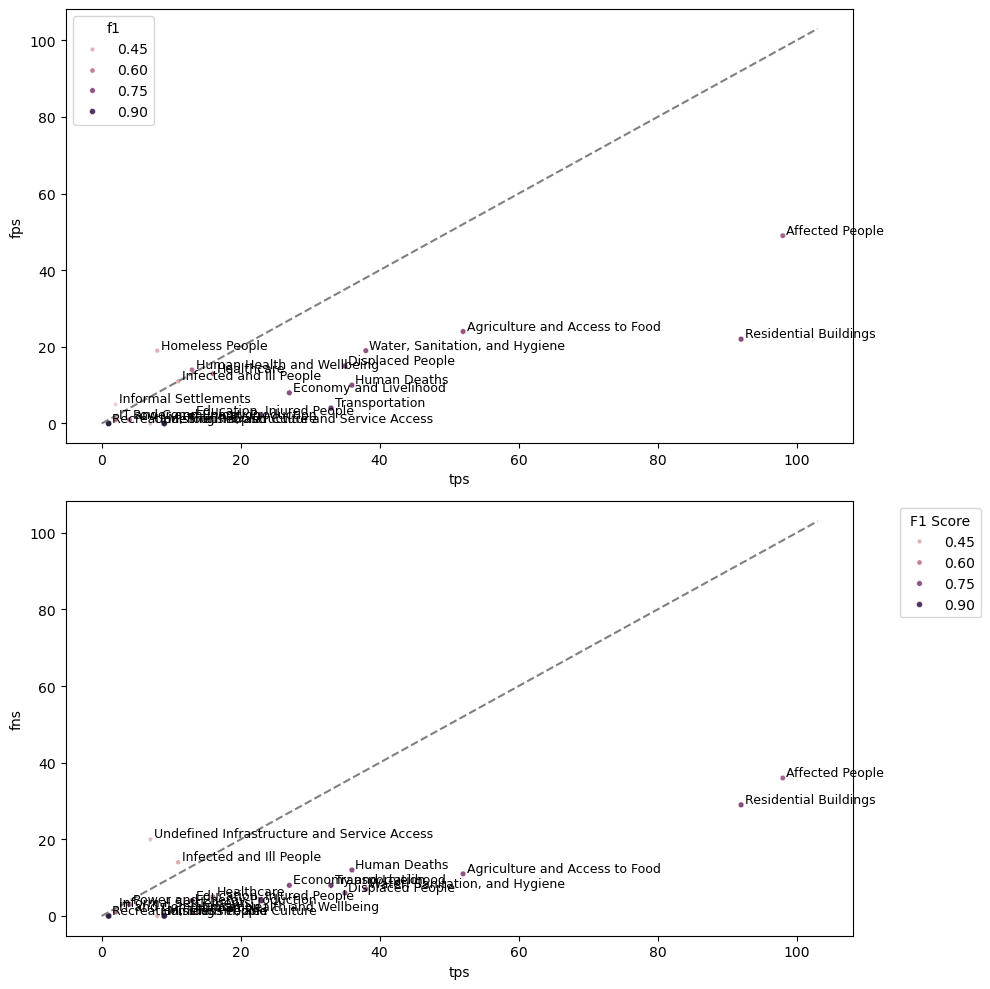

In [119]:
import seaborn as sns

fig, axes = plt.subplots(ncols=1, nrows=2, figsize=(10,10))
xkey = "tps"
ykeys = ["fps", "fns"]
for i, ykey in enumerate(ykeys):
    ax = axes[i]

    sns.scatterplot(
        ax=ax,
        data=f1_bs_by_subtype,
        x=xkey,
        y=ykey,
        hue="f1",
        size="f1",
        sizes=(10, 20),
        legend=True,
    )
    # add impact subtype text
    for i, row in f1_bs_by_subtype.iterrows():
        ax.text(row[xkey]+0.5, row[ykey]+0.5, row["impactSubtype"], fontsize=9)

    # add 1-1 line
    max_val = max(f1_bs_by_subtype[xkey].max(), f1_bs_by_subtype[ykey].max()) + 5
    ax.plot([0, max_val], [0, max_val], color="gray", linestyle="--")
    #ax.set_xlabel("Number of extracted impacts")
    #ax.set_ylabel("Number of labelled impacts")
    #ax.set_title("True Positives by Impact Subtype")
plt.legend(title="F1 Score", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

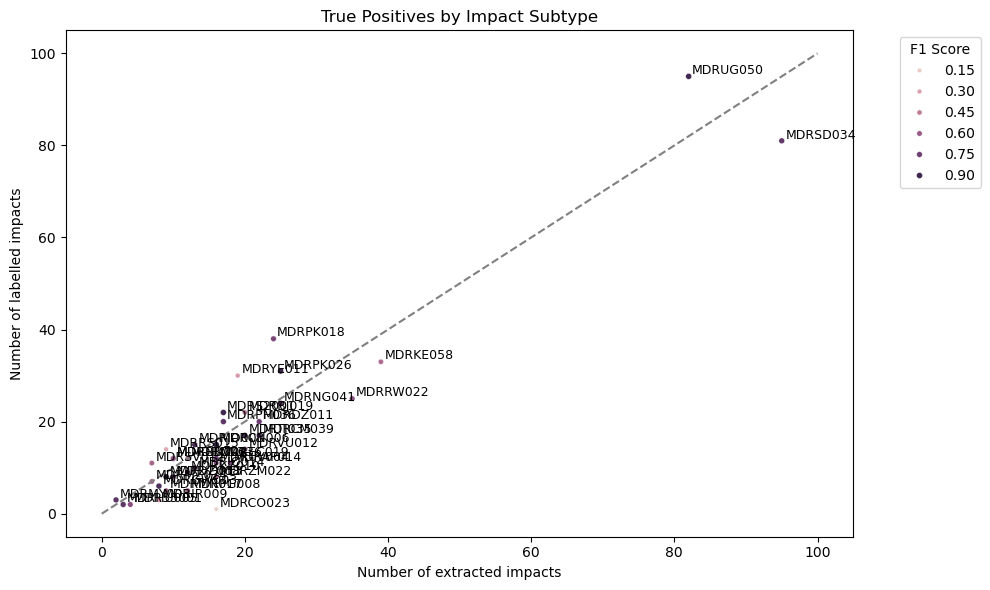

In [120]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    ax=ax,
    data=f1_bs_by_appeal,
    x="n_ext",
    y="n_lab",
    hue="f1",
    size="f1",
    sizes=(10, 20),
    legend=True,
)

# add impact subtype text
for i, row in f1_bs_by_appeal.iterrows():
    ax.text(row["n_ext"] + 0.5, row["n_lab"] + 0.5, row["appealCode"], fontsize=9)

# add 1-1 line
max_val = max(f1_bs_by_appeal["n_ext"].max(), f1_bs_by_appeal["n_lab"].max()) + 5
ax.plot([0, max_val], [0, max_val], color="gray", linestyle="--")
ax.set_xlabel("Number of extracted impacts")
ax.set_ylabel("Number of labelled impacts")
ax.set_title("True Positives by Impact Subtype")
plt.legend(title="F1 Score", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

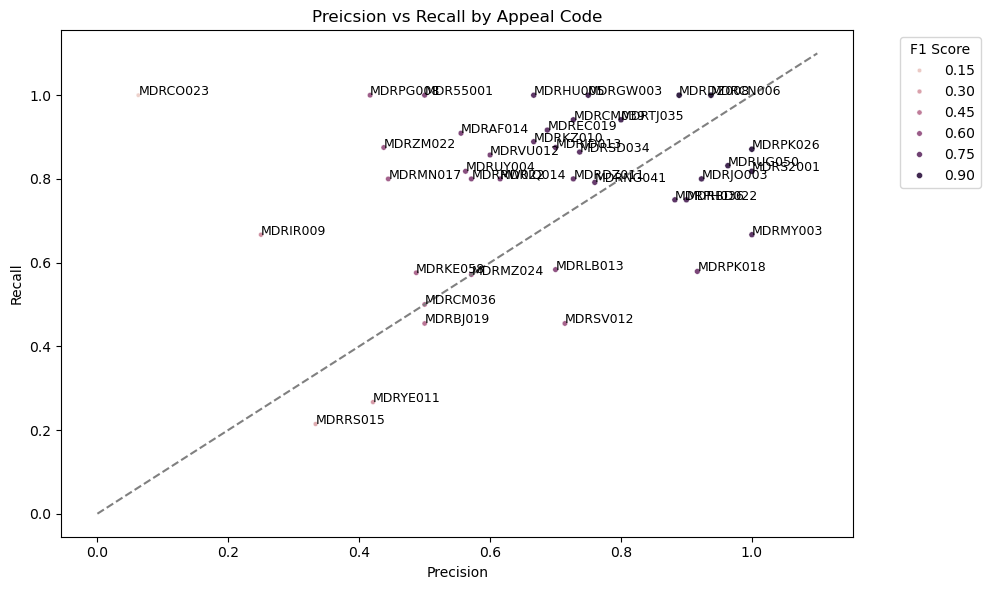

In [121]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    ax=ax,
    data=f1_bs_by_appeal,
    x="precision",
    y="recall",
    hue="f1",
    size="f1",
    sizes=(10, 20),
    legend=True,
)

# add impact subtype text
for i, row in f1_bs_by_appeal.iterrows():
    ax.text(row["precision"], row["recall"], row["appealCode"], fontsize=9)

# add 1-1 line
max_val = max(f1_bs_by_appeal["precision"].max(), f1_bs_by_appeal["recall"].max()) + 0.1
ax.plot([0, max_val], [0, max_val], color="gray", linestyle="--")
ax.set_xlabel("Precision")
ax.set_ylabel("Recall")
ax.set_title("Preicsion vs Recall by Appeal Code")
plt.legend(title="F1 Score", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

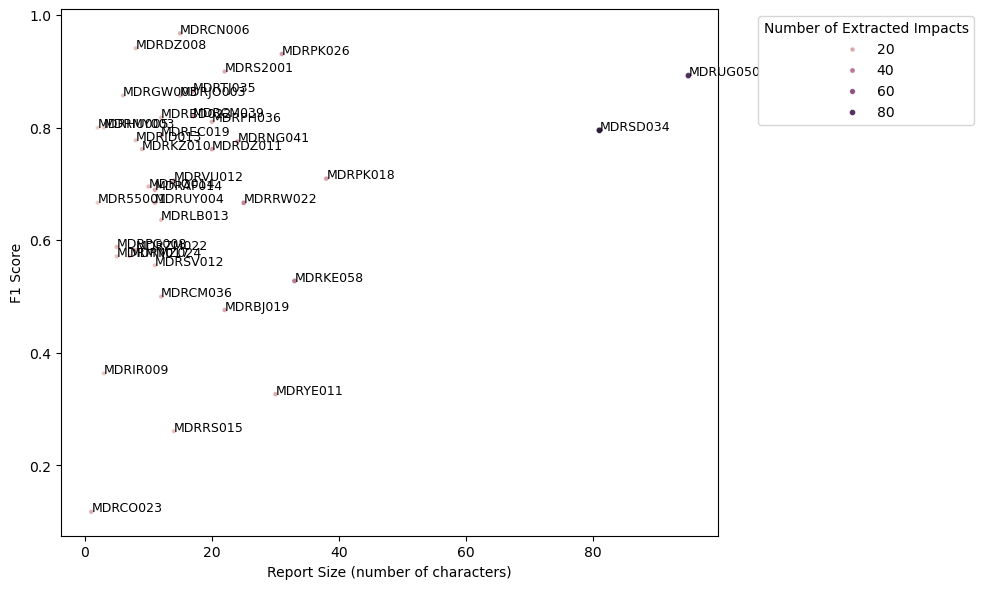

In [122]:
fig, ax = plt.subplots(figsize=(10, 6))
xkey="n_lab"
ykey="f1"
sns.scatterplot(
    ax=ax,
    data=f1_bs_by_appeal,
    x=xkey,
    y=ykey,
    hue="n_ext",
    size="n_ext",
    sizes=(10, 20),
    legend=True,
)

# add impact subtype text
for i, row in f1_bs_by_appeal.iterrows():
    ax.text(row[xkey], row[ykey], row["appealCode"], fontsize=9)

# add 1-1 line
#max_val = max(f1_bs_by_appeal[xkey].max(), f1_bs_by_appeal[ykey].max()) + 5
#ax.plot([0, max_val], [0, max_val], color="gray", linestyle="--")
ax.set_xlabel("Report Size (number of characters)")
ax.set_ylabel("F1 Score")
#ax.set_title("")
plt.legend(title="Number of Extracted Impacts", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

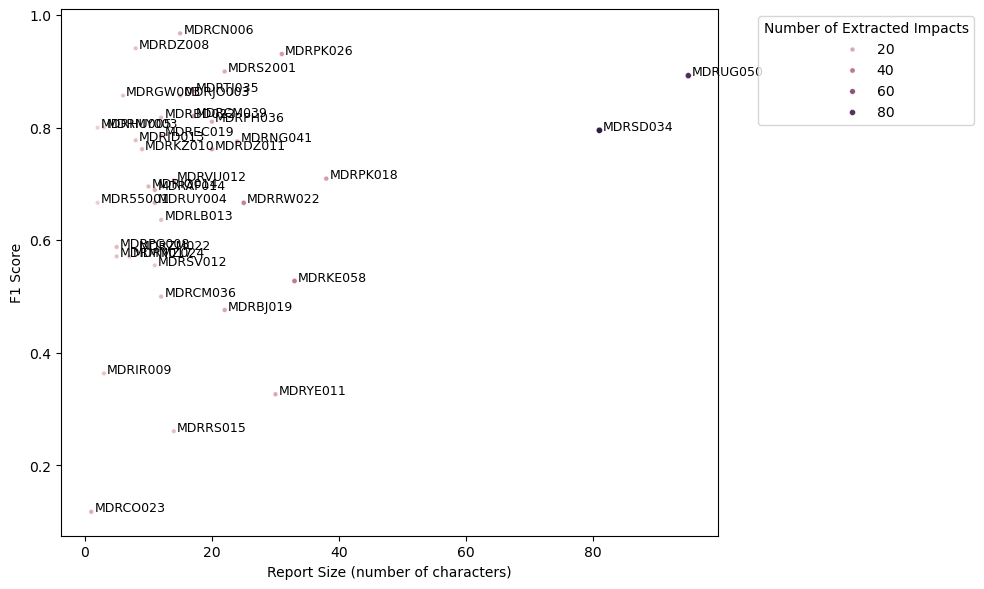

In [123]:
fig, ax = plt.subplots(figsize=(10, 6))
xkey = "n_lab"
ykey = "f1"
sns.scatterplot(
    ax=ax,
    data=f1_bs_by_appeal,
    x=xkey,
    y=ykey,
    hue="n_ext",
    size="n_ext",
    sizes=(10, 20),
    legend=True,
)

# add impact subtype text
for i, row in f1_bs_by_appeal.iterrows():
    ax.text(row[xkey] + 0.5, row[ykey], row["appealCode"], fontsize=9)

# add 1-1 line
# max_val = max(f1_bs_by_appeal[xkey].max(), f1_bs_by_appeal[ykey].max()) + 5
# ax.plot([0, max_val], [0, max_val], color="gray", linestyle="--")
ax.set_xlabel("Report Size (number of characters)")
ax.set_ylabel("F1 Score")
# ax.set_title("")
plt.legend(
    title="Number of Extracted Impacts", bbox_to_anchor=(1.05, 1), loc="upper left"
)
plt.tight_layout()
plt.show()

<Axes: xlabel='tps', ylabel='f1'>

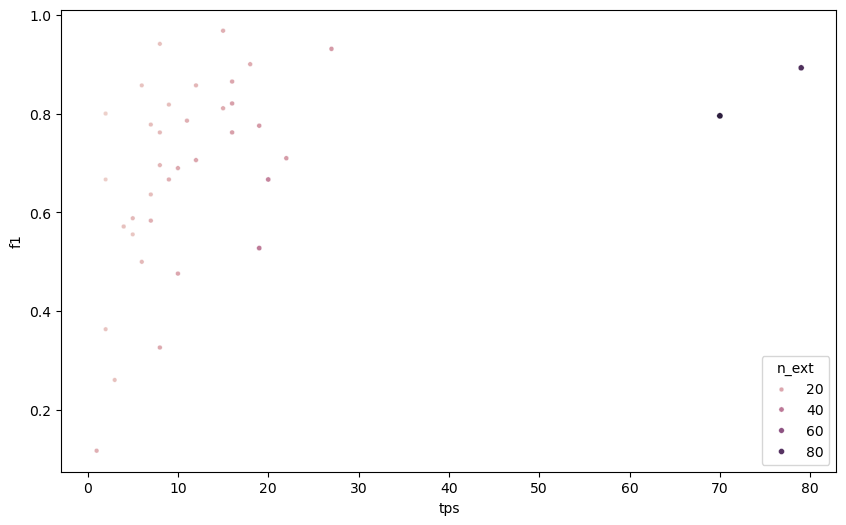

In [124]:
fig, ax = plt.subplots(figsize=(10, 6))
xkey = "tps"
ykey = "f1"
sns.scatterplot(
    ax=ax,
    data=f1_bs_by_appeal,
    x=xkey,
    y=ykey,
    hue="n_ext",
    size="n_ext",
    sizes=(10, 20),
    legend=True,
)

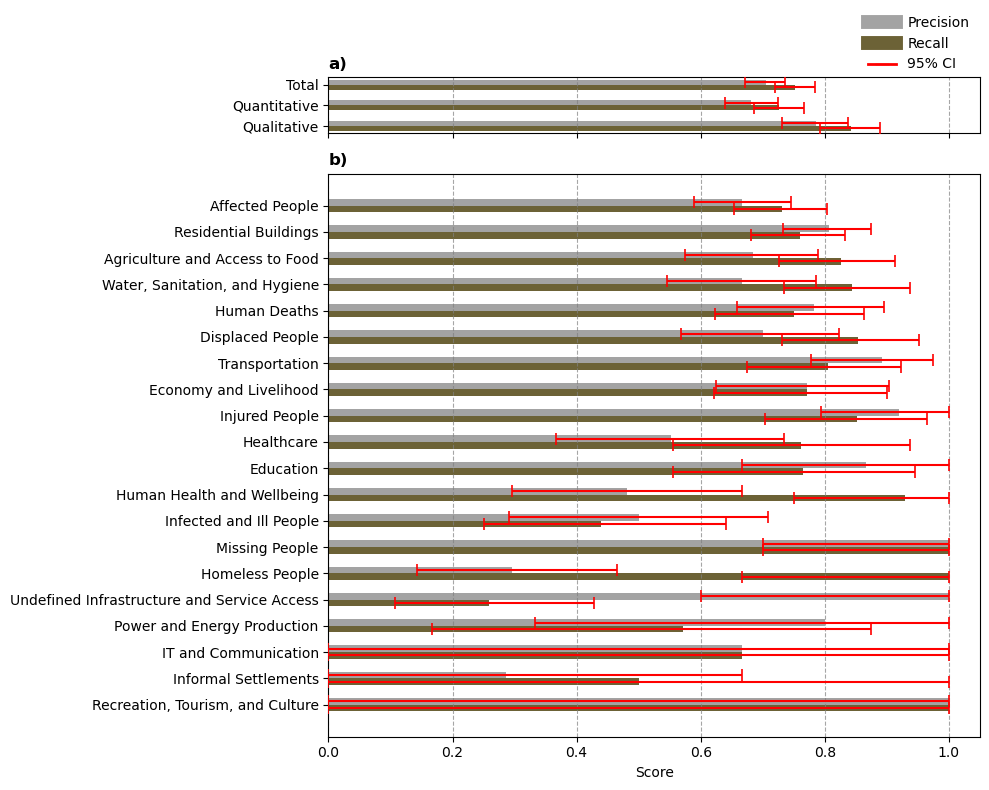

In [125]:

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

metrics = ["precision", "recall"]#"f1"
colors = ["#a3a3a3", "#6c6236", "#5e0eff"]  # distinct colors for each metric
group_key = "impactSubtype"


fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharey=False, sharex=True, height_ratios=[1, 10])

# --- Function to plot grouped bars with error bars ---
def plot_metrics_with_errorbars(ax, df, x_col, metrics, colors):
    if isinstance(df, pd.Series):
        df = df.to_frame().T
    n_metrics = len(metrics)
    y_positions = np.arange(len(df))
    height = 0.25  # controls bar thickness
    spacing = 0.3  # space between metric groups

    for i, metric in enumerate(metrics):
        # compute shifted y positions for each metric
        offset = (i - (n_metrics - 1)/2) * height
        y_shifted = y_positions + offset

        val = np.atleast_1d(df[f"{metric}"])
        lower = np.atleast_1d(df[f"{metric}_low_err"])
        upper = np.atleast_1d(df[f"{metric}_high_err"])

        ax.barh(
            y_shifted,
            val,
            height=height,
            color=colors[i],
            label=metric.capitalize()
        )

        # Add horizontal error bars
        xerr = [lower, upper]
        ax.errorbar(
            val, y_shifted, xerr=xerr,
            fmt='none', ecolor='red',
            elinewidth=1.5, capsize=4, capthick=1.2, zorder=5
        )

    ax.set_yticks(y_positions)
    ax.set_yticklabels(df[x_col])
    ax.invert_yaxis()
    ax.set_xlim(0, 1.05)  # adjust if scores in [0,1]

# --- Plot bottom panel (all-level metrics) ---
plot_metrics_with_errorbars(ax[0], f1_bs_all, "quanti", metrics, colors)

# --- Plot top panel (by-key metrics) ---
plot_metrics_with_errorbars(ax[1], f1_bs_by_subtype, group_key, metrics, colors)

# --- Labels ---
ax[1].set_xlabel("Score")
ax[0].set_ylabel("")
ax[1].set_ylabel("")

# --- Create combined legend handles ---
err_proxy = Line2D([0], [0], color='red', lw=2, marker='_', markersize=10, label='95% CI')
bars_proxy = [Line2D([0], [0], color=c, lw=10, label=m.capitalize()) for m, c in zip(metrics, colors)]

# --- Add legend ---
#ax[1].get_legend().remove()
ax[0].legend(handles=bars_proxy + [err_proxy], loc=(0.82, 1), frameon=False)#title="Metrics"

ax[0].set_title("a)", fontweight="bold", loc="left")
ax[1].set_title("b)", fontweight="bold", loc="left")

## add grids
ax[0].xaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.7)
ax[1].xaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.7)

plt.tight_layout()
plt.show()

fig.savefig(DATA_FIGURE / f"{'_'.join(metrics)}_vth-{value_error_th}_sth-{sim_th}_flt_{filename_match.replace(key, MODEL_NAMES_MAP[key])}.png", bbox_inches="tight", dpi=600)

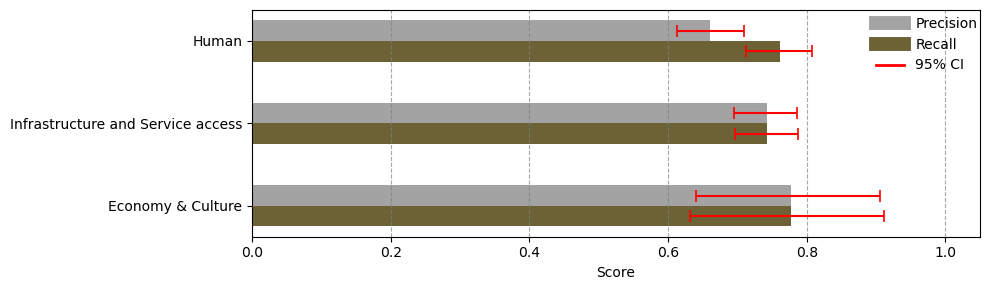

In [126]:
metrics = ["precision", "recall"]  # "f1"
colors = ["#a3a3a3", "#6c6236", "#5e0eff"]  # distinct colors for each metric
group_key = "impactType"

data = f1_bs_by_maintype

fig, ax = plt.subplots(
    1, 1, figsize=(10, 3), sharey=False, sharex=False#, height_ratios=[1, 10]
)
ax = [ax]  # make ax a list for compatibility with plotting function
# --- Plot bottom panel (all-level metrics) ---
plot_metrics_with_errorbars(ax[0], data, group_key, metrics, colors)

# --- Plot top panel (by-key metrics) ---
# plot_metrics_with_errorbars(ax[1], f1_bs_by_subtype, group_key, metrics, colors)

# --- Labels ---
ax[0].set_xlabel("Score")
ax[0].set_ylabel("")

# --- Create combined legend handles ---
err_proxy = Line2D(
    [0], [0], color="red", lw=2, marker="_", markersize=10, label="95% CI"
)
bars_proxy = [
    Line2D([0], [0], color=c, lw=10, label=m.capitalize())
    for m, c in zip(metrics, colors)
]

# --- Add legend ---
# ax[1].get_legend().remove()
ax[0].legend(
    handles=bars_proxy + [err_proxy], loc=(0.85, 0.7), frameon=False
)  # title="Metrics"

# ax[0].set_title("a)", fontweight="bold", loc="left")
# ax[1].set_title("b)", fontweight="bold", loc="left")

## add grids
ax[0].xaxis.grid(True, linestyle="--", which="major", color="grey", alpha=0.7)
# ax[1].xaxis.grid(True, linestyle="--", which="major", color="grey", alpha=0.7)

plt.tight_layout()
plt.show()

fig.savefig(
    DATA_FIGURE
    / f"precision_recall_maintypes_EGU26.png",
    bbox_inches="tight",
    dpi=600,
)

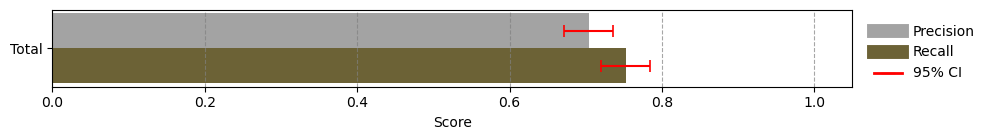

In [127]:
metrics = ["precision", "recall"]  # "f1"
colors = ["#a3a3a3", "#6c6236", "#5e0eff"]  # distinct colors for each metric
group_key = "quanti"

data = f1_bs_all.set_index("quanti", drop=False).loc["Total"]

fig, ax = plt.subplots(
    1, 1, figsize=(10, 1.5), sharey=False, sharex=False  # , height_ratios=[1, 10]
)
ax = [ax]  # make ax a list for compatibility with plotting function
# --- Plot bottom panel (all-level metrics) ---
plot_metrics_with_errorbars(ax[0], data, group_key, metrics, colors)

# --- Plot top panel (by-key metrics) ---
# plot_metrics_with_errorbars(ax[1], f1_bs_by_subtype, group_key, metrics, colors)

# --- Labels ---
ax[0].set_xlabel("Score")
ax[0].set_ylabel("")

# --- Create combined legend handles ---
err_proxy = Line2D(
    [0], [0], color="red", lw=2, marker="_", markersize=10, label="95% CI"
)
bars_proxy = [
    Line2D([0], [0], color=c, lw=10, label=m.capitalize())
    for m, c in zip(metrics, colors)
]

# --- Add legend ---
# ax[1].get_legend().remove()
ax[0].legend(
    handles=bars_proxy + [err_proxy], loc=(1.02, 0.01), frameon=False,
    ncol=1
)  # title="Metrics"

# ax[0].set_title("a)", fontweight="bold", loc="left")
# ax[1].set_title("b)", fontweight="bold", loc="left")

## add grids
ax[0].xaxis.grid(True, linestyle="--", which="major", color="grey", alpha=0.7)
# ax[1].xaxis.grid(True, linestyle="--", which="major", color="grey", alpha=0.7)

plt.tight_layout()
plt.show()

fig.savefig(
    DATA_FIGURE / f"precision_recall_total_EGU26.png",
    bbox_inches="tight",
    dpi=600,
)

In [128]:
f1_bs_by_subtype

,impactSubtype,tps,n_ext,n_lab,fps,fns,f1,precision,recall,f1_low_err,f1_high_err,precision_low_err,precision_high_err,recall_low_err,recall_high_err
0,Affected People,98,147,134,49,36,0.697509,0.666667,0.731343,0.063181,0.057593,0.077626,0.078431,0.077497,0.071474
8,Residential Buildings,92,114,121,22,29,0.782979,0.807018,0.760331,0.065490,0.054420,0.074875,0.067982,0.080003,0.071602
20,Agriculture and Access to Food,52,76,63,24,11,0.748201,0.684211,0.825397,0.086663,0.076123,0.108868,0.105263,0.099590,0.086884
16,"Water, Sanitation, and Hygiene",38,57,45,19,7,0.745098,0.666667,0.844444,0.106800,0.080590,0.121252,0.119048,0.109751,0.093056
5,Human Deaths,36,46,48,10,12,0.765957,0.782609,0.750000,0.099291,0.085528,0.124835,0.113225,0.127778,0.112767
2,Displaced People,35,50,41,15,6,0.769231,0.700000,0.853659,0.102564,0.087912,0.131373,0.123529,0.121951,0.098722
15,Transportation,33,37,41,4,8,0.846154,0.891892,0.804878,0.096154,0.082418,0.114114,0.083108,0.130459,0.118199
11,Economy and Livelihood,27,35,35,8,8,0.771429,0.771429,0.771429,0.136508,0.096992,0.146429,0.131797,0.149807,0.128571
1,Injured People,23,25,27,2,4,0.884615,0.920000,0.851852,0.093591,0.079670,0.126932,0.080000,0.148148,0.112434
17,Healthcare,16,29,21,13,5,0.640000,0.551724,0.761905,0.185455,0.145714,0.185057,0.181609,0.206349,0.175595


In [129]:
f1_bs_all

,quanti,n_ext,n_lab,tps,fps,fns,f1,precision,recall,f1_low_err,f1_high_err,precision_low_err,precision_high_err,recall_low_err,recall_high_err
0,Total,738,691,520,218,171,0.727782,0.704607,0.752533,0.026353,0.025305,0.033393,0.031599,0.032304,0.032352
0,Quantitative,495,464,337,158,127,0.702815,0.680808,0.726293,0.033297,0.032957,0.041135,0.042853,0.040272,0.040743
0,Qualitative,243,227,191,52,36,0.812766,0.786008,0.841410,0.041841,0.036719,0.054301,0.051492,0.049374,0.046984


In [130]:
un_matched = matched_df_filter1[(matched_df_filter1["match_sim"] <= sim_th)]
un_matched_quali = un_matched[(matched_df_filter1["quanti"] == "quali")]
un_matched_quanti = un_matched[(matched_df_filter1["quanti"] == "quanti")]


/Users/lseverino/miniforge3/envs/ifrc_llm_311/lib/python3.11/site-packages/geopandas/geodataframe.py:1896: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  result = super().__getitem__(key)
/Users/lseverino/miniforge3/envs/ifrc_llm_311/lib/python3.11/site-packages/geopandas/geodataframe.py:1896: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  result = super().__getitem__(key)


In [131]:
# inspect sensitivity to thresholds

value_error_ths = np.arange(0.01, 0.3, 0.01)
sim_ths = np.arange(0.2, 1, 0.1)
vth_scores = []
n_lab = len(labelled_df_filter)
n_ext = len(extracted_df_filter)
for vth in value_error_ths:
    matched_df_filter = filter_matches(matched_df, value_error_th=vth, sim_th=0.6)
    tps = true_positives(matched_df_filter)
    fps = false_positives(n_ext, tps)
    fns = false_negatives(n_lab, tps)
    precisions = precision_bt(tps, fps)
    recalls = recall_bt(tps, fns)
    f1s = f1_bt(tps, fps, fns)
    vth_scores.append(pd.DataFrame({"value_error_th": [vth], "sim_th": [0.6], "True positives": [tps], "False positives": [fps], "precision": [precisions], "recall": [recalls], "f1": [f1s]}))

sth_scores = []
for sth in sim_ths:
    matched_df_filter = filter_matches(matched_df, value_error_th=0.1, sim_th=sth)
    tps = true_positives(matched_df_filter)
    fps = false_positives(n_ext, tps)
    fns = false_negatives(n_lab, tps)
    precisions = precision_bt(tps, fps)
    recalls = recall_bt(tps, fns)
    f1s = f1_bt(tps, fps, fns)
    sth_scores.append(pd.DataFrame({"value_error_th": [0.1], "sim_th": [sth], "True positives": [tps], "False positives": [fps], "precision": [precisions], "recall": [recalls], "f1": [f1s]}))

<Axes: >

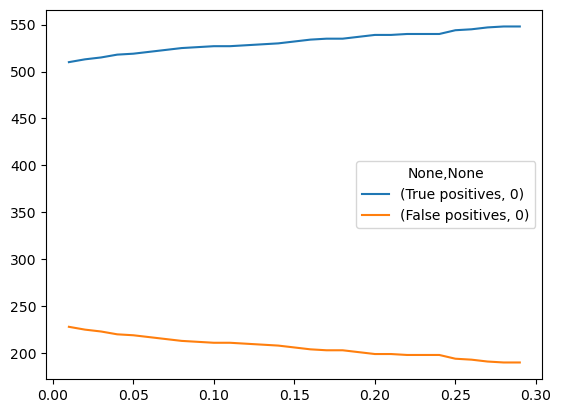

In [132]:
sensi_vth_df = pd.concat(vth_scores, keys=value_error_ths).unstack()
sensi_vth_df[["True positives", "False positives"]].plot()

<Axes: >

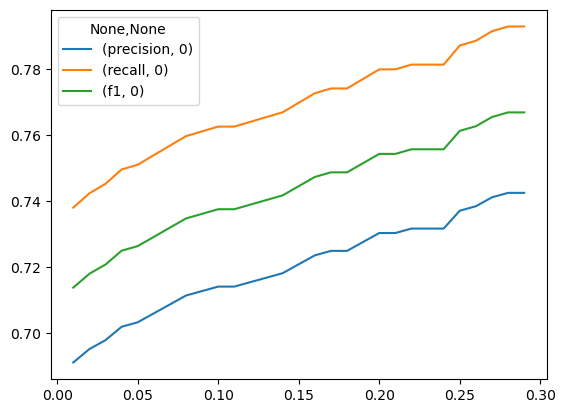

In [133]:
sensi_vth_df[["precision", "recall", "f1"]].plot()

<Axes: >

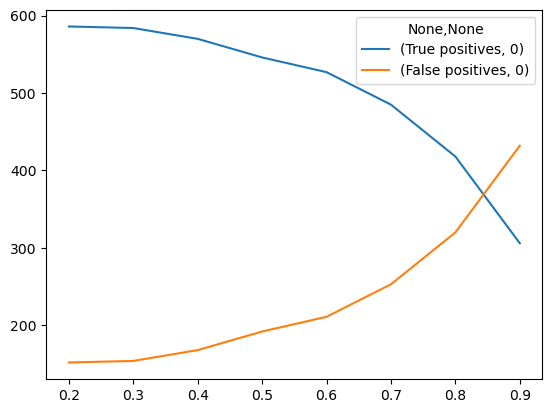

In [134]:
sensi_sth_df = pd.concat(sth_scores, keys=sim_ths).unstack()
sensi_sth_df[["True positives", "False positives"]].plot()

<Axes: >

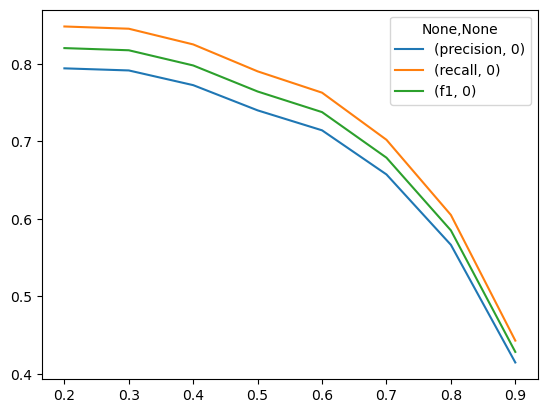

In [135]:
sensi_sth_df[["precision", "recall", "f1"]].plot()